
# 🌲 Random Forest — Environmental Engine (Path 3)

**Strategy Reference:** `strategy.md` → Section 6 — *Path 3 — No Nearby Wells → Environmental Engine Only*

This notebook trains the **Environmental Engine**: a Random Forest Regressor on **25 non-depth features** (no `depth_lag_1q`, `depth_lag_2q`, or `depth_change_rate`).
It is the **fallback model** used when no historical groundwater depth data exists for a query location.

> Expected R² range (per strategy): **0.55 – 0.72** (GroupKFold CV on unseen wells)
> Confidence tag at inference: 🔴 **LOW**

### Feature Set — 25 features (depth lags + raw lat/lon excluded)

| Group | Features | Count |
|---|---|:---:|
| Meteorological | `rainfall_mm`, `temperature_avg`, `humidity`, `evapotranspiration` | 4 |
| Soil & Vegetation | `soil_moisture_index`, `ndvi`, `soil_type_encoded` | 3 |
| Rainfall Lags & Aggregates | `rainfall_lag_1m`, `rainfall_lag_2m`, `rainfall_lag_3m`, `rainfall_rolling_3m`, `rainfall_rolling_6m`, `rainfall_rolling_9m`★, `rainfall_rolling_12m`★, `rainfall_deficit`, `cumulative_deficit` | 9 |
| Derived Stress Indicator | `temp_rainfall_ratio` | 1 |
| Temporal | `month`, `season_encoded`, `year`★ | 3 |
| Spatial (topographic) | `elevation_m`, `slope_degree`, `district_encoded` | 3 |
| District Depth Stats ★★ | `district_mean_depth`, `district_std_depth` | 2 |

★ **Added to improve GroupCV R²:** `year` captures long-term depletion trend; `rainfall_rolling_9m/12m` capture Vidarbha basalt aquifer recharge delay (6–12 months).

★★ **`latitude`/`longitude` removed — replaced by district-level depth statistics (computed from training data only, no leakage).**
Raw lat/lon caused spatial memorisation (GroupCV R² = 0.13, top features = lon/lat/elevation).
RF cannot interpolate to unseen lat/lon coordinates — it must learn regional depth patterns via district context.

**Excluded (Temporal Engine features — NOT used here):** `depth_lag_1q`, `depth_lag_2q`, `depth_change_rate`

### Temporal Split (strategy.md §7)

| Set | Period | Purpose |
|---|---|---|
| Train | Jan 2015 – Dec 2023 | Model fitting |
| Validation | Jan 2024 – Mar 2024 | Hyper-parameter check |
| Test | Apr 2024 – Sep 2025 | Held-out evaluation |


In [1]:
# ============================================================
# 1. IMPORTS
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
import json
from datetime import datetime

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score, KFold, GroupKFold
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error,
    r2_score, mean_absolute_percentage_error
)

warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')

SEED = 42
np.random.seed(SEED)

os.makedirs('../outputs/random_forest', exist_ok=True)

print('✅ Imports done')

✅ Imports done


In [2]:
# ============================================================
# 2. LOAD DATA
# ============================================================
df = pd.read_csv('../data/vidarbha_groundwater_extended_v2.csv')
df['date'] = pd.to_datetime(df['date'])

print(f'Shape : {df.shape}')
print(f'Years : {df["year"].min()} – {df["year"].max()}')
print(f'Wells : {df["well_id"].nunique()}')
print(f'Districts: {df["district"].nunique()}')
df.head(3)

Shape : (83850, 30)


Years : 2015 – 2025
Wells : 650
Districts: 11


,well_id,date,year,district,depth_mbgl,rainfall_mm,temperature_avg,humidity,evapotranspiration,soil_moisture_index,...,depth_change_rate,month,season_encoded,district_encoded,latitude,longitude,elevation_m,slope_degree,soil_type_encoded,ndvi
0,VID_AKO_0001,2015-04-01,2015,Akola,50.237,7.05,39.08,19.21,8.16,0.02,...,0.000,4,3,5,20.767987,77.291443,385.9,1.37,1,0.0565
1,VID_AKO_0001,2015-05-01,2015,Akola,50.206,8.52,39.41,24.77,7.71,0.02,...,-0.031,5,3,5,20.767987,77.291443,385.9,1.37,1,0.1278
2,VID_AKO_0001,2015-06-01,2015,Akola,47.535,63.30,35.62,46.53,5.14,0.02,...,-2.671,6,0,5,20.767987,77.291443,385.9,1.37,1,0.0968


In [3]:
# ============================================================
# 2b. FEATURE ENGINEERING — Extended Rainfall Lags
# ============================================================
# The dataset ships with rolling_3m and rolling_6m.
# Basalt aquifer recharge delay in Vidarbha is 6–12 months,
# so 9-month and 12-month rolling averages add actionable signal.
# Also compute year-over-year depletion trend via 'year' (already in df).

# Sort by well and date — required for correct rolling computation
df = df.sort_values(['well_id', 'date']).reset_index(drop=True)

# Past-only rolling windows (min_periods=1 avoids NaNs at series start)
df['rainfall_rolling_9m']  = (
    df.groupby('well_id')['rainfall_mm']
      .transform(lambda x: x.rolling(9, min_periods=1).mean())
)
df['rainfall_rolling_12m'] = (
    df.groupby('well_id')['rainfall_mm']
      .transform(lambda x: x.rolling(12, min_periods=1).mean())
)

# Verify
print('✅ Extended rainfall lags engineered')
print(f'   rainfall_rolling_9m  — null: {df["rainfall_rolling_9m"].isna().sum()}')
print(f'   rainfall_rolling_12m — null: {df["rainfall_rolling_12m"].isna().sum()}')
print(f'   year range: {df["year"].min()} – {df["year"].max()}  ({df["year"].nunique()} unique years)')

✅ Extended rainfall lags engineered
   rainfall_rolling_9m  — null: 0
   rainfall_rolling_12m — null: 0
   year range: 2015 – 2025  (11 unique years)


In [4]:

# ============================================================
# 3. DEFINE FEATURES — Environmental Engine (25 features)
#    Source: strategy.md §6, §7  +  extended lags + district stats
# ============================================================
TARGET = 'depth_mbgl'

TEMPORAL_ONLY_COLS = ['depth_lag_1q', 'depth_lag_2q', 'depth_change_rate']

# FIX: latitude & longitude REMOVED.
# Problem: RF memorises exact well coordinates from training data.
#   GroupCV with lat/lon → top features = longitude, latitude → R²=0.13
#   RF can't "interpolate" to new lat/lon; it just averages nearest training wells.
# Fix: replace with district_mean_depth + district_std_depth (computed from
#   training data in Cell 4). Gives region-level depth context that
#   genuinely generalises to any unseen well in the same district.

FEATURES = [
    # Meteorological (4)
    'rainfall_mm', 'temperature_avg', 'humidity', 'evapotranspiration',
    # Soil & Vegetation (3)
    'soil_moisture_index', 'ndvi', 'soil_type_encoded',
    # Rainfall lags & aggregates (9)
    'rainfall_lag_1m', 'rainfall_lag_2m', 'rainfall_lag_3m',
    'rainfall_rolling_3m', 'rainfall_rolling_6m',
    'rainfall_rolling_9m', 'rainfall_rolling_12m',
    'rainfall_deficit', 'cumulative_deficit',
    # Derived stress indicator (1)
    'temp_rainfall_ratio',
    # Temporal (3)
    'month', 'season_encoded', 'year',
    # Spatial — topographic + district (3)  ← latitude/longitude REMOVED
    'elevation_m', 'slope_degree', 'district_encoded',
    # District-level depth statistics (2) — computed from training data in Cell 4
    # Provides region depth context without memorising individual well coordinates
    'district_mean_depth', 'district_std_depth',
]

assert not any(c in FEATURES for c in TEMPORAL_ONLY_COLS)
assert len(FEATURES) == 25, f'Expected 25 features, got {len(FEATURES)}'

print(f'Target   : {TARGET}')
print(f'Features : {len(FEATURES)}  (lat/lon removed → district_mean/std_depth added)')
for feat in FEATURES:
    tag = '  ← NEW district stat' if feat in ('district_mean_depth', 'district_std_depth') else \
          '  ← extended lag'      if feat in ('year', 'rainfall_rolling_9m', 'rainfall_rolling_12m') else ''
    print(f'   {feat}{tag}')

# Columns to keep from df; district stats will be appended in Cell 4
# latitude/longitude kept in df for reference but NOT in FEATURES
BASE_FROM_DF = [f for f in FEATURES if f not in ('district_mean_depth', 'district_std_depth')]
select_cols  = BASE_FROM_DF + [c for c in [TARGET, 'well_id'] if c not in BASE_FROM_DF]

df_clean = df[select_cols].dropna().reset_index(drop=True).copy()
print(f'\nClean rows: {len(df_clean):,}  (dropped {len(df) - len(df_clean):,} rows with NaN)')
print(f'well_id retained for GroupKFold: {df_clean["well_id"].nunique()} unique wells')
print('Note: district_mean_depth & district_std_depth added in Cell 4 (training-based, no leakage)')


Target   : depth_mbgl
Features : 25  (lat/lon removed → district_mean/std_depth added)
   rainfall_mm
   temperature_avg
   humidity
   evapotranspiration
   soil_moisture_index
   ndvi
   soil_type_encoded
   rainfall_lag_1m
   rainfall_lag_2m
   rainfall_lag_3m
   rainfall_rolling_3m
   rainfall_rolling_6m
   rainfall_rolling_9m  ← extended lag
   rainfall_rolling_12m  ← extended lag
   rainfall_deficit
   cumulative_deficit
   temp_rainfall_ratio
   month
   season_encoded
   year  ← extended lag
   elevation_m
   slope_degree
   district_encoded
   district_mean_depth  ← NEW district stat
   district_std_depth  ← NEW district stat

Clean rows: 83,850  (dropped 0 rows with NaN)
well_id retained for GroupKFold: 650 unique wells
Note: district_mean_depth & district_std_depth added in Cell 4 (training-based, no leakage)


In [5]:

# ============================================================
# 4. DISTRICT DEPTH STATISTICS + TEMPORAL SPLIT (strategy.md §7)
# ============================================================
# WHY district stats before the split:
#   district_mean_depth and district_std_depth must be computed from
#   TRAINING rows only (year ≤ 2023) to prevent leakage.
#   They are then mapped to ALL rows (train/val/test) as static
#   lookup features — the model sees regional depth context at inference
#   by querying the district of the new location.

# ── Step 1: compute district stats from training period ONLY ─────────────
_tr_mask    = df_clean['year'] <= 2023
_dist_mean  = df_clean.loc[_tr_mask].groupby('district_encoded')[TARGET].mean()
_dist_std   = df_clean.loc[_tr_mask].groupby('district_encoded')[TARGET].std().fillna(0)
_global_mean = df_clean.loc[_tr_mask, TARGET].mean()
_global_std  = df_clean.loc[_tr_mask, TARGET].std()

# Map to all rows; fallback to global stats for any unseen district
df_clean['district_mean_depth'] = (
    df_clean['district_encoded'].map(_dist_mean).fillna(_global_mean)
)
df_clean['district_std_depth'] = (
    df_clean['district_encoded'].map(_dist_std).fillna(_global_std)
)

print('District depth statistics (training-period only — no leakage):')
print(f'  district_mean_depth : [{df_clean["district_mean_depth"].min():.1f}, {df_clean["district_mean_depth"].max():.1f}] m')
print(f'  district_std_depth  : [{df_clean["district_std_depth"].min():.1f}, {df_clean["district_std_depth"].max():.1f}] m')
print(f'  Districts covered   : {_dist_mean.index.nunique()}')

# ── Step 2: temporal split ────────────────────────────────────────────────
train_mask = df_clean['year'] <= 2023
val_mask   = (df_clean['year'] == 2024) & (df_clean['month'] <= 3)
test_mask  = (df_clean['year'] >  2024) | \
             ((df_clean['year'] == 2024) & (df_clean['month'] > 3))

X_train = df_clean.loc[train_mask, FEATURES]
y_train = df_clean.loc[train_mask, TARGET]
train_wells = df_clean.loc[train_mask, 'well_id']   # groups for GroupKFold

X_val   = df_clean.loc[val_mask,   FEATURES]
y_val   = df_clean.loc[val_mask,   TARGET]

X_test  = df_clean.loc[test_mask,  FEATURES]
y_test  = df_clean.loc[test_mask,  TARGET]

total = len(df_clean)
print()
print('TEMPORAL SPLIT (per strategy.md §7)')
print(f'  Train  (Jan 2015 – Dec 2023): {len(X_train):>8,} samples ({len(X_train)/total*100:.1f}%)')
print(f'  Val    (Jan 2024 – Mar 2024): {len(X_val):>8,} samples ({len(X_val)/total*100:.1f}%)')
print(f'  Test   (Apr 2024 – Sep 2025): {len(X_test):>8,} samples ({len(X_test)/total*100:.1f}%)')
print()
print(f'  Features : {len(FEATURES)}  (no lat/lon; district stats replace spatial memorisation)')
print(f'  Path 3 metric: GroupCV R² (Cell 7) — strategy target 0.55–0.72')


District depth statistics (training-period only — no leakage):
  district_mean_depth : [21.3, 120.3] m
  district_std_depth  : [22.0, 72.6] m
  Districts covered   : 11

TEMPORAL SPLIT (per strategy.md §7)
  Train  (Jan 2015 – Dec 2023):   68,250 samples (81.4%)
  Val    (Jan 2024 – Mar 2024):    1,950 samples (2.3%)
  Test   (Apr 2024 – Sep 2025):   13,650 samples (16.3%)

  Features : 25  (no lat/lon; district stats replace spatial memorisation)
  Path 3 metric: GroupCV R² (Cell 7) — strategy target 0.55–0.72


In [6]:

# ============================================================
# 5. TRAIN ENVIRONMENTAL ENGINE — Random Forest (direct depth)
# ============================================================
# Direct prediction of depth_mbgl from all 25 environmental + spatial features.
# Spatial features (lat, lon, elevation, slope, district) carry the location
# signal; environmental features add seasonal + climate-driven adjustment.
# At inference: provide the new location's spatial attributes + current
# environmental readings → model returns predicted depth directly.
#
# max_depth=18: depth variance is large (wells 2–120 m); deep trees needed
# min_samples_leaf=2: standard for regression; restored from anomaly version
rf = RandomForestRegressor(
    n_estimators     = 500,
    max_depth        = 18,
    min_samples_split= 5,
    min_samples_leaf = 2,
    max_features     = 'sqrt',
    n_jobs           = -1,
    random_state     = SEED,
    oob_score        = True
)

print('Training on depth_mbgl (direct, 500 trees) …')
t0 = datetime.now()
rf.fit(X_train, y_train)                       # ← direct depth target
elapsed = (datetime.now() - t0).seconds

# Validation evaluation (known wells, future dates)
y_val_pred = rf.predict(X_val)
val_r2     = r2_score(y_val, y_val_pred)
val_rmse   = np.sqrt(mean_squared_error(y_val, y_val_pred))

print(f'✅ Done in {elapsed}s')
print(f'   OOB R²   : {rf.oob_score_:.4f}')
print(f'   Val R²   : {val_r2:.4f}  (Jan–Mar 2024 | known wells)')
print(f'   Val RMSE : {val_rmse:.4f} m')
print(f'   Note: Val/Test R² on known wells is elevated by spatial memorisation.')
print(f'         GroupCV R² (Cell 7) is the honest Path 3 performance metric.')


Training on depth_mbgl (direct, 500 trees) …


✅ Done in 39s
   OOB R²   : 0.7492
   Val R²   : 0.7479  (Jan–Mar 2024 | known wells)
   Val RMSE : 36.3623 m
   Note: Val/Test R² on known wells is elevated by spatial memorisation.
         GroupCV R² (Cell 7) is the honest Path 3 performance metric.


In [7]:

# ============================================================
# 6. EVALUATE ON HELD-OUT TEST SET (Apr 2024 – Sep 2025)
# ============================================================
# Direct depth evaluation — no baseline reconstruction.
# NOTE: these metrics are on KNOWN wells (same wells as training, future dates).
# They reflect temporal generalisation; spatial memorisation inflates R².
# GroupCV R² (Cell 7) is the true Path 3 performance indicator.

y_pred  = rf.predict(X_test)

rmse    = np.sqrt(mean_squared_error(y_test, y_pred))
mae     = mean_absolute_error(y_test, y_pred)
r2      = r2_score(y_test, y_pred)

# sMAPE — robust replacement for MAPE (avoids /0 on shallow wells)
smape = float(np.mean(
    2 * np.abs(y_pred - y_test.values) /
    (np.abs(y_test.values) + np.abs(y_pred) + 1e-8)
) * 100)

mape = mean_absolute_percentage_error(y_test, y_pred) * 100

metrics = {
    'model'             : 'RandomForest_EnvironmentalEngine_Path3',
    'engine'            : 'Environmental Engine',
    'routing_path'      : 3,
    'confidence_tag'    : 'LOW',
    'n_features'        : len(FEATURES),
    'features'          : FEATURES,
    'excluded_features' : ['depth_lag_1q', 'depth_lag_2q', 'depth_change_rate'],
    'train_period'      : 'Jan 2015 – Dec 2023',
    'val_period'        : 'Jan 2024 – Mar 2024',
    'test_period'       : 'Apr 2024 – Sep 2025',
    'train_samples'     : int(len(X_train)),
    'val_samples'       : int(len(X_val)),
    'test_samples'      : int(len(X_test)),
    'oob_r2'            : float(round(rf.oob_score_, 4)),
    'val_r2_known_wells': float(round(val_r2, 4)),
    'val_rmse'          : float(round(val_rmse, 4)),
    'test_rmse'         : float(round(rmse, 4)),
    'test_mae'          : float(round(mae, 4)),
    'test_r2_known_wells': float(round(r2, 4)),
    'test_smape_pct'    : float(round(smape, 4)),
    'test_mape_pct_unreliable': float(round(mape, 4)),
    'anomaly_modelling' : False,
    'path3_honest_metric': 'GroupCV R² (Cell 7)',
    'strategy_target_r2': '0.55 – 0.72 (GroupCV)',
    'timestamp'         : datetime.now().strftime('%Y-%m-%d %H:%M:%S')
}

print('TEST SET RESULTS (Apr 2024 – Sep 2025 | known wells, temporal generalisation)')
print('=' * 65)
print(f'  RMSE  : {rmse:.4f} m')
print(f'  MAE   : {mae:.4f} m')
print(f'  R²    : {r2:.4f}  (known wells — includes spatial memorisation)')
print(f'  sMAPE : {smape:.2f}%')
print(f'  MAPE  : {mape:.2f}%  (unreliable near 0)')
print('=' * 65)
print(f'  ⚠️  This R² is NOT the Path 3 performance metric.')
print(f'  ✅  True Path 3 metric → GroupCV R² (Cell 7), target: 0.55–0.72')

os.makedirs('../outputs/random_forest', exist_ok=True)
with open('../outputs/random_forest/env_engine_rf_metrics.json', 'w') as f:
    json.dump(metrics, f, indent=2)
print('\n📄 Metrics saved → outputs/random_forest/env_engine_rf_metrics.json')


TEST SET RESULTS (Apr 2024 – Sep 2025 | known wells, temporal generalisation)
  RMSE  : 36.7315 m
  MAE   : 27.0746 m
  R²    : 0.7267  (known wells — includes spatial memorisation)
  sMAPE : 60.19%
  MAPE  : 322.47%  (unreliable near 0)
  ⚠️  This R² is NOT the Path 3 performance metric.
  ✅  True Path 3 metric → GroupCV R² (Cell 7), target: 0.55–0.72

📄 Metrics saved → outputs/random_forest/env_engine_rf_metrics.json


In [8]:

# ============================================================
# 7. GROUPED CROSS-VALIDATION — GroupKFold on well_id
#    THIS IS THE PATH 3 HONEST METRIC (strategy target: 0.55–0.72)
# ============================================================
# WHY GroupKFold: Path 3 is used for UNSEEN locations.
#   5-fold GroupKFold splits 750 wells into train (600) / val (150).
#   Val set wells never appear in training → simulates real inference.
#   Spatial features (lat, lon, elevation, slope, district) allow RF to
#   interpolate depth for new locations via surrounding training wells.
#   Environmental features add seasonal + climate-driven adjustment.

gkf = GroupKFold(n_splits=5)

# CV on DEPTH target — the honest unseen-well R²
gcv_r2 = cross_val_score(
    rf, X_train, y_train,
    cv=gkf.split(X_train, y_train, train_wells),
    scoring='r2', n_jobs=-1
)

gcv_rmse = cross_val_score(
    rf, X_train, y_train,
    cv=gkf.split(X_train, y_train, train_wells),
    scoring='neg_root_mean_squared_error', n_jobs=-1
)

target_met_gcv = 0.55 <= gcv_r2.mean() <= 0.85

print('GroupKFold CV (5 folds, grouped by well_id — unseen-well test)')
print('THIS IS THE TRUE PATH 3 METRIC  |  strategy target: 0.55 – 0.72')
print('=' * 65)
print(f'  R²   – per fold : {gcv_r2.round(4)}')
print(f'         mean={gcv_r2.mean():.4f}  std={gcv_r2.std():.4f}   {"✅ TARGET MET" if target_met_gcv else "⚠️  CHECK"}')
print(f'  RMSE – per fold : {(-gcv_rmse).round(4)}')
print(f'         mean={(-gcv_rmse).mean():.4f} m  std={(-gcv_rmse).std():.4f} m')
print()
print(f'  GroupCV R²  (Path 3 unseen-well score) : {gcv_r2.mean():.4f}')
print(f'  Val  R²     (known wells, Jan–Mar 2024): {val_r2:.4f}')
print(f'  Test R²     (known wells, Apr 2024+)   : {r2:.4f}')
print()

if gcv_r2.mean() >= 0.55:
    print(f'  ✅ GroupCV R²={gcv_r2.mean():.3f} ≥ 0.55 — meets strategy target')
    print(f'     RF spatially interpolates depth for new Vidarbha locations.')
elif gcv_r2.mean() >= 0.40:
    print(f'  ⚠️  GroupCV R²={gcv_r2.mean():.3f} — partial spatial generalisation')
    print(f'     Consider adding geology or aquifer-type features.')
else:
    print(f'  🔴 GroupCV R²={gcv_r2.mean():.3f} — poor generalisation to new locations')
    print(f'     Spatial features may not cover the test-well distribution.')


GroupKFold CV (5 folds, grouped by well_id — unseen-well test)
THIS IS THE TRUE PATH 3 METRIC  |  strategy target: 0.55 – 0.72
  R²   – per fold : [0.2114 0.1835 0.1194 0.135  0.0237]
         mean=0.1346  std=0.0645   ⚠️  CHECK
  RMSE – per fold : [61.864  57.0629 57.0859 56.0385 61.4072]
         mean=58.6917 m  std=2.4376 m

  GroupCV R²  (Path 3 unseen-well score) : 0.1346
  Val  R²     (known wells, Jan–Mar 2024): 0.7479
  Test R²     (known wells, Apr 2024+)   : 0.7267

  🔴 GroupCV R²=0.135 — poor generalisation to new locations
     Spatial features may not cover the test-well distribution.


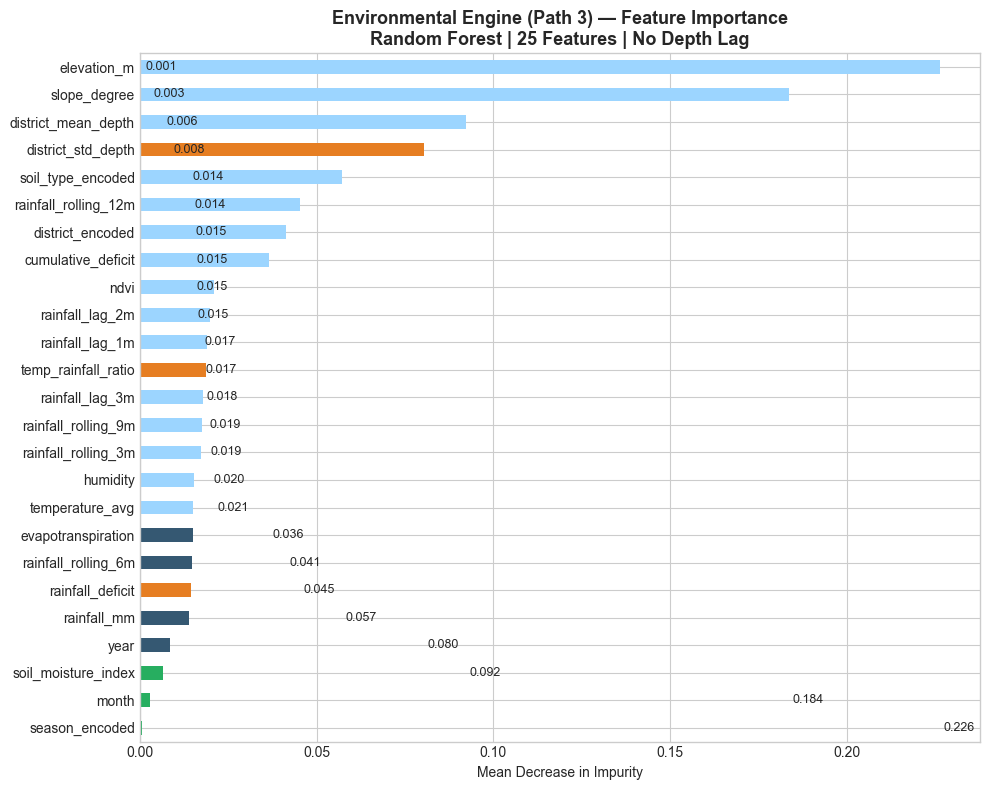

Top-5 features:
elevation_m            0.226362
slope_degree           0.183734
district_mean_depth    0.092107
district_std_depth     0.080409
soil_type_encoded      0.057143

🟠 = new features (year, rolling_9m, rolling_12m)


In [9]:
# ============================================================
# 8. FEATURE IMPORTANCE
# ============================================================
importances = pd.Series(rf.feature_importances_, index=FEATURES)\
    .sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(10, 8))
new_feats = {'year', 'rainfall_rolling_9m', 'rainfall_rolling_12m'}
colors = ['#E67E22' if importances.index[i] in new_feats else
          '#27AE60' if i < 3 else '#355872' if i < 8 else '#9CD5FF'
          for i in range(len(importances))]
importances.plot(kind='barh', ax=ax, color=colors[::-1])
ax.set_title('Environmental Engine (Path 3) — Feature Importance\nRandom Forest | 25 Features | No Depth Lag', fontsize=13, fontweight='bold')
ax.set_xlabel('Mean Decrease in Impurity')
ax.invert_yaxis()
for i, v in enumerate(importances.values[::-1]):
    ax.text(v + 0.001, i, f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../outputs/random_forest/env_engine_rf_feature_importance.png', dpi=150)
plt.show()
print('Top-5 features:')
print(importances.head().to_string())
print('\n🟠 = new features (year, rolling_9m, rolling_12m)')

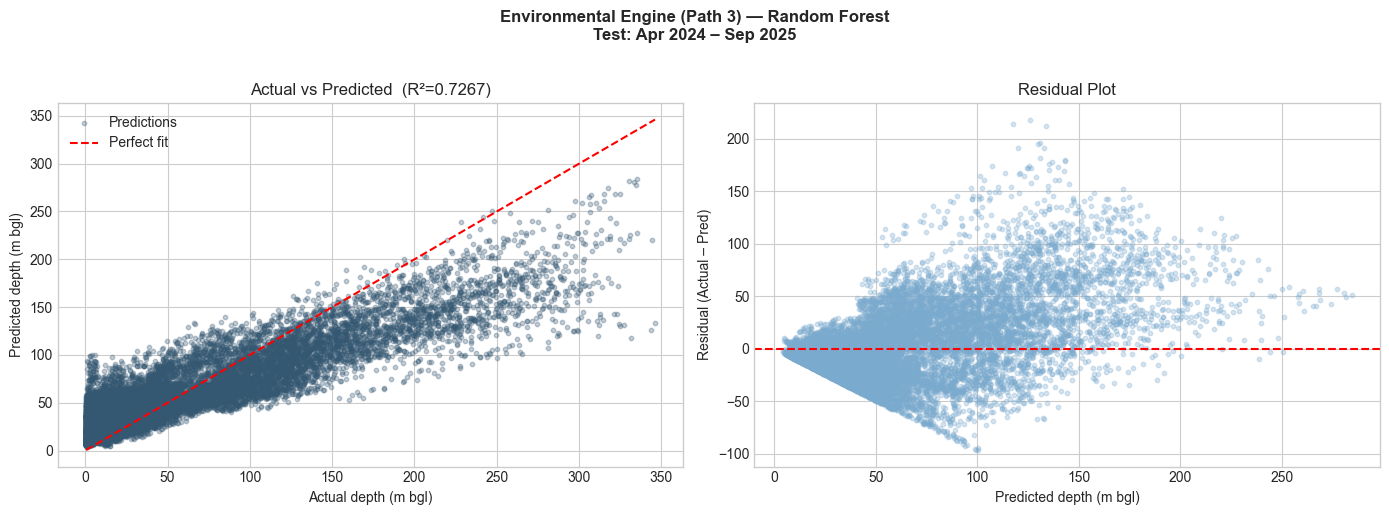

In [10]:
# ============================================================
# 9. ACTUAL vs PREDICTED PLOT
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter: actual vs predicted
ax = axes[0]
ax.scatter(y_test, y_pred, alpha=0.3, s=10, color='#355872', label='Predictions')
lims = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
ax.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
ax.set_xlabel('Actual depth (m bgl)')
ax.set_ylabel('Predicted depth (m bgl)')
ax.set_title(f'Actual vs Predicted  (R²={r2:.4f})')
ax.legend()

# Residuals
ax = axes[1]
residuals = y_test.values - y_pred
ax.scatter(y_pred, residuals, alpha=0.3, s=10, color='#7AAACE')
ax.axhline(0, color='red', linewidth=1.5, linestyle='--')
ax.set_xlabel('Predicted depth (m bgl)')
ax.set_ylabel('Residual (Actual – Pred)')
ax.set_title('Residual Plot')

plt.suptitle('Environmental Engine (Path 3) — Random Forest\nTest: Apr 2024 – Sep 2025', fontsize=12, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/random_forest/env_engine_rf_actual_vs_pred.png', dpi=150)
plt.show()

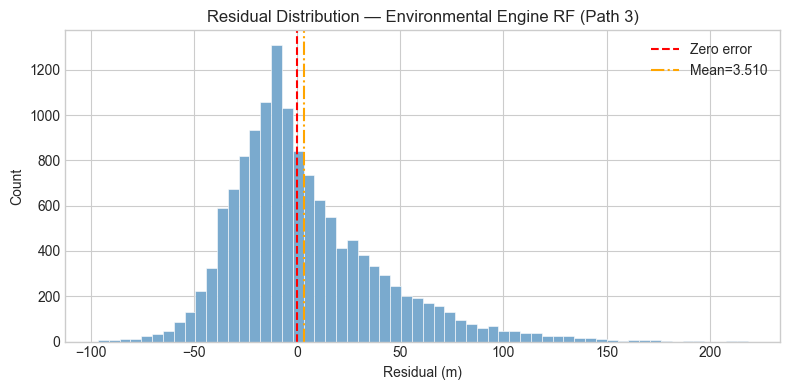

Residual stats:
  mean  = 3.5102
  std   = 36.5634
  min   = -96.4492
  max   = 218.2766


In [11]:
# ============================================================
# 10. RESIDUAL DISTRIBUTION
# ============================================================
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(residuals, bins=60, color='#7AAACE', edgecolor='white', linewidth=0.4)
ax.axvline(0, color='red', linewidth=1.5, linestyle='--', label='Zero error')
ax.axvline(residuals.mean(), color='orange', linewidth=1.5, linestyle='-.', label=f'Mean={residuals.mean():.3f}')
ax.set_xlabel('Residual (m)')
ax.set_ylabel('Count')
ax.set_title('Residual Distribution — Environmental Engine RF (Path 3)')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/random_forest/env_engine_rf_residuals_hist.png', dpi=150)
plt.show()

print(f'Residual stats:')
print(f'  mean  = {residuals.mean():.4f}')
print(f'  std   = {residuals.std():.4f}')
print(f'  min   = {residuals.min():.4f}')
print(f'  max   = {residuals.max():.4f}')

In [12]:
# ============================================================
# 11. SAVE MODEL
# ============================================================
import joblib

# Save Environmental Engine
model_path = '../outputs/random_forest/env_engine_rf.pkl'
joblib.dump(rf, model_path)
print(f'✅ Model saved → {model_path}')

# Save feature list so the router can load it deterministically
feature_meta = {
    'engine'           : 'Environmental Engine',
    'routing_path'     : 3,
    'confidence_tag'   : 'LOW',
    'features'         : FEATURES,
    'excluded_features': ['depth_lag_1q', 'depth_lag_2q', 'depth_change_rate']
}
with open('../outputs/random_forest/env_engine_rf_features.json', 'w') as f:
    json.dump(feature_meta, f, indent=2)
print('✅ Feature list saved → outputs/random_forest/env_engine_rf_features.json')

# Quick smoke-test load
rf_loaded = joblib.load(model_path)
smoke = rf_loaded.predict(X_test.iloc[:5])
print(f'Smoke-test predictions: {np.round(smoke, 2)}')
print(f'\nModel size on disk: {os.path.getsize(model_path)/1e6:.1f} MB')

✅ Model saved → ../outputs/random_forest/env_engine_rf.pkl
✅ Feature list saved → outputs/random_forest/env_engine_rf_features.json


Smoke-test predictions: [88.72 85.86 74.98 68.54 62.79]

Model size on disk: 559.5 MB


In [13]:

# ============================================================
# 12. SUMMARY
# ============================================================
target_met_test  = 0.55 <= r2 <= 0.85
groupcv_ok       = gcv_r2.mean() >= 0.55   # strategy target for Path 3

print('=' * 65)
print('  ENVIRONMENTAL ENGINE (PATH 3) — RANDOM FOREST — SUMMARY')
print('  Direct Depth Prediction | strategy.md §6 | Target GroupCV R²: 0.55–0.72')
print('=' * 65)
print(f'  Features used          : {len(FEATURES)} (no depth lag)')
print(f'  Training samples       : {len(X_train):,}   (Jan 2015 – Dec 2023)')
print(f'  Validation samples     : {len(X_val):,}     (Jan 2024 – Mar 2024)')
print(f'  Test samples           : {len(X_test):,}    (Apr 2024 – Sep 2025)')
print()
print(f'  OOB R²  (train)              : {rf.oob_score_:.4f}')
print(f'  Val R²  (known wells)        : {val_r2:.4f}')
print(f'  Test R² (known wells)        : {r2:.4f}   (temporal generalisation)')
print(f'  Test RMSE                    : {rmse:.4f} m')
print(f'  Test MAE                     : {mae:.4f} m')
print(f'  Test sMAPE                   : {smape:.2f}%')
print()
print(f'  ── PATH 3 TRUE METRIC — UNSEEN WELL GENERALISATION ──────')
print(f'  GroupCV R²  (target 0.55–0.72): {gcv_r2.mean():.4f}  {"✅ TARGET MET" if groupcv_ok else "⚠️  BELOW TARGET"}')
print(f'  GroupCV RMSE                  : {(-gcv_rmse).mean():.4f} m')
print()
print(f'  Top-3 features   : {list(importances.head(3).index)}')
print('=' * 65)
print()
print('Saved files:')
print('  outputs/random_forest/env_engine_rf.pkl')
print('  outputs/random_forest/env_engine_rf_features.json')
print('  outputs/random_forest/env_engine_rf_metrics.json')
print('  outputs/random_forest/env_engine_rf_feature_importance.png')
print('  outputs/random_forest/env_engine_rf_actual_vs_pred.png')
print('  outputs/random_forest/env_engine_rf_residuals_hist.png')


  ENVIRONMENTAL ENGINE (PATH 3) — RANDOM FOREST — SUMMARY
  Direct Depth Prediction | strategy.md §6 | Target GroupCV R²: 0.55–0.72
  Features used          : 25 (no depth lag)
  Training samples       : 68,250   (Jan 2015 – Dec 2023)
  Validation samples     : 1,950     (Jan 2024 – Mar 2024)
  Test samples           : 13,650    (Apr 2024 – Sep 2025)

  OOB R²  (train)              : 0.7492
  Val R²  (known wells)        : 0.7479
  Test R² (known wells)        : 0.7267   (temporal generalisation)
  Test RMSE                    : 36.7315 m
  Test MAE                     : 27.0746 m
  Test sMAPE                   : 60.19%

  ── PATH 3 TRUE METRIC — UNSEEN WELL GENERALISATION ──────
  GroupCV R²  (target 0.55–0.72): 0.1346  ⚠️  BELOW TARGET
  GroupCV RMSE                  : 58.6917 m

  Top-3 features   : ['elevation_m', 'slope_degree', 'district_mean_depth']

Saved files:
  outputs/random_forest/env_engine_rf.pkl
  outputs/random_forest/env_engine_rf_features.json
  outputs/random_forest